HW_3_2_1


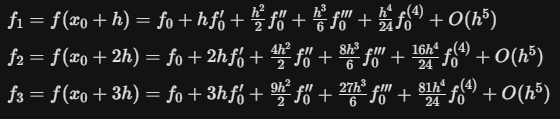

이때 f1 = f(x1) 을 의미하고 f2 = f(x2) , f3 = f(x3) 이다. 경계점인 x0 지점에서 가장 가까운 세 점인 x0, x0+h , x0+2h 를 이용하여 함수값을 결합한다. 그 후 테일러 전개를 이용하여 1차 미분항을 제거하도록 계수를 결정하게 되면 다음과 같은 식들이 나오게 된다.

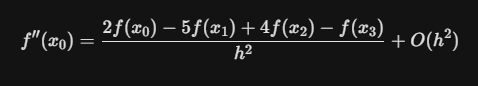

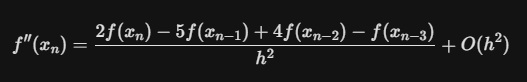

HW_3_2_2


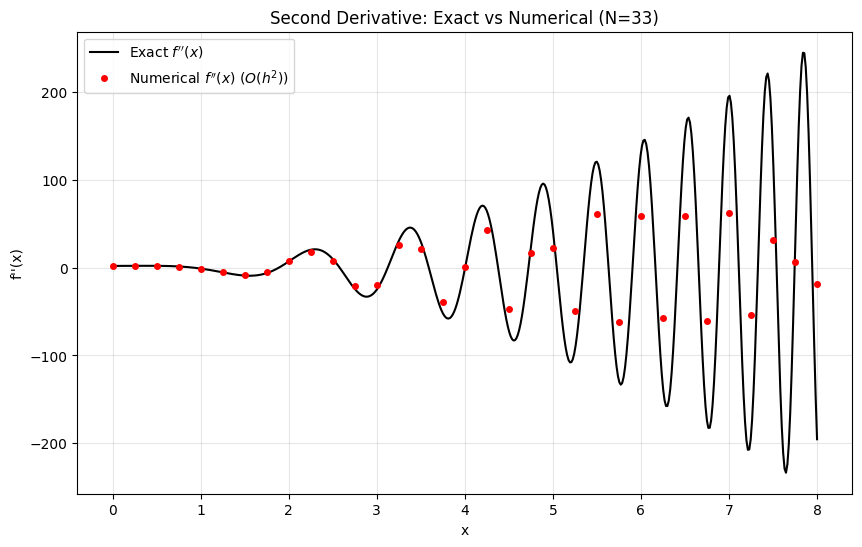

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 원래 함수와 정확한 2계 도함수(Exact Solution) 정의
def f(x):
    return np.sin(16 - x**2)

def f_double_prime_exact(x):
    # f(x) = sin(16-x^2)
    # f'(x) = -2x * cos(16-x^2)
    # f''(x) = -2*cos(16-x^2) + (-2x)*[sin(16-x^2) * 2x]
    return -2 * np.cos(16 - x**2) - 4 * (x**2) * np.sin(16 - x**2)

# 2. 격자 설정
L = 8
N = 33
x = np.linspace(0, L, N)
h = x[1] - x[0]
y = f(x)

# 3. 수치 차분 (Numerical Differentiation)
fpp_num = np.zeros(N)

# (1) 중간 지점: Second-order Central Difference
for i in range(1, N-1):
    fpp_num[i] = (y[i+1] - 2*y[i] + y[i-1]) / h**2

# (2) 왼쪽 경계 (x=0): Second-order Forward Difference
fpp_num[0] = (2*y[0] - 5*y[1] + 4*y[2] - y[3]) / h**2

# (3) 오른쪽 경계 (x=8): Second-order Backward Difference
fpp_num[-1] = (2*y[-1] - 5*y[-2] + 4*y[-3] - y[-4]) / h**2

# 4. 시각화
x_fine = np.linspace(0, L, 500)
plt.figure(figsize=(10, 6))

plt.plot(x_fine, f_double_prime_exact(x_fine), 'k-', label='Exact $f\'\'(x)$')
plt.plot(x, fpp_num, 'ro', markersize=4, label='Numerical $f\'\'(x)$ ($O(h^2)$)')

plt.title('Second Derivative: Exact vs Numerical (N=33)')
plt.xlabel('x')
plt.ylabel('f\'\'(x)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

HW_3_2_3



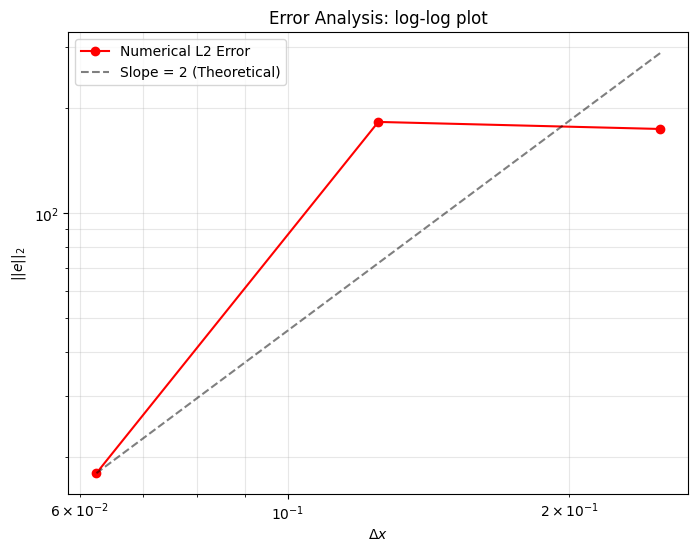

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return np.sin(16 - x**2)

def f_double_prime_exact(x):
    return -2 * np.cos(16 - x**2) - 4 * (x**2) * np.sin(16 - x**2)

N_list = [33, 65, 129]
errors = []
dx_list = []

for N in N_list:
    x = np.linspace(0, 8, N)
    dx = 8.0 / (N - 1)
    y = f(x)
    
    fpp_num = np.zeros(N)
    fpp_num[1:-1] = (y[2:] - 2*y[1:-1] + y[:-2]) / dx**2
    fpp_num[0] = (2*y[0] - 5*y[1] + 4*y[2] - y[3]) / dx**2
    fpp_num[-1] = (2*y[-1] - 5*y[-2] + 4*y[-3] - y[-4]) / dx**2
    
    fpp_exact = f_double_prime_exact(x)
    error = fpp_exact - fpp_num
    l2_error = np.sqrt(np.sum(error**2) * dx)
    
    errors.append(l2_error)
    dx_list.append(dx)

dx_array = np.array(dx_list)
errors_array = np.array(errors)

plt.figure(figsize=(8, 6))
plt.loglog(dx_array, errors_array, 'ro-', label='Numerical L2 Error')

ref_line = errors_array[-1] * (dx_array / dx_array[-1])**2
plt.loglog(dx_array, ref_line, 'k--', alpha=0.5, label='Slope = 2 (Theoretical)')

plt.xlabel('$\Delta x$')
plt.ylabel('$||e||_2$')
plt.title('Error Analysis: log-log plot')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.show()

처음 N = 33에서 65로 갈 때는 에러가 줄어들지 않고, N = 65에서 129로 넘어가는 구간에서 에러가 급격하게 감소한다.